### Stochastic interpolant demo: unit Gaussian → 2D Gaussian Mixture

A minimal, self-contained illustration of the `eesi` interpolant framework in 2D.

We learn a generative map from a simple **base** distribution to a more complex
**target**:

- **Base** `p_0`: a single 2D Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1`: a mixture of Gaussians with non-zero (tilted) covariances.

The `EESI` model trains a drift field `b(t, x)` and a score field `s(t, x)` along
the stochastic interpolant

$$x_t = \alpha(t)\,x_0 + \beta(t)\,x_1 + \gamma(t)\,z,\qquad z\sim N(0, I),$$

then integrates the learned probability-flow ODE (or reverse-time SDE) from
`t=0` (base) to `t=1` (target). This notebook covers **setup & instantiation**,
the **training loop**, **sampling**, and **contour plotting**.

In [19]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
from torch.distributions import MultivariateNormal

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
from eesi import EESI, TimeMLP, GaussianMixture, ConstrainedMLP

%matplotlib inline
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a two-component Gaussian
mixture built from `eesi.datasets.GaussianMixture`, whose weights, means and
full (correlated) covariances are drawn once from a fixed `seed` and then held
constant.

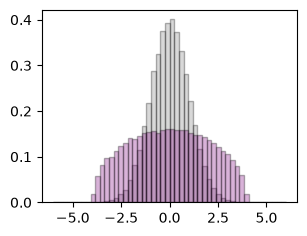

In [20]:
# --- base: single 2D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(1, device=device), torch.eye(1, device=device))

# --- target: 2-component Gaussian mixture from eesi.datasets.GaussianMixture ---
# The mixture draws its weights, means and full covariances once (fixed `seed`)
# and then holds them constant; `sigma` sets how far apart the component means
# are, and `device` keeps all parameters on the GPU when available.
#target = GaussianMixture(d=1, n=1, sigma=3, seed=5, device=device)
#target = MultivariateNormal(torch.zeros(1, device=device), 4*torch.eye(1, device=device))
target = torch.distributions.Beta(torch.tensor([1.5], device=device), 
                            torch.tensor([1.5], device=device))

# Sanity check: draw and scatter samples from each distribution.
scale = 4
x0_vis = base.sample((100000,)).cpu()
x1_vis = 2*scale*(target.sample((100000,)).cpu()-0.5)

# Symmetric plot limits that comfortably contain both distributions.
LIM = float(torch.cat([x0_vis, x1_vis]).abs().max().ceil()) + 1.0

"""
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
ax[0].scatter(x0_vis[:, 0], x0_vis[:, 1], s=4, alpha=0.3, c="steelblue")
ax[0].set_title("base  $p_0 = N(0, I)$")
ax[1].scatter(x1_vis[:, 0], x1_vis[:, 1], s=4, alpha=0.3, c="crimson")
ax[1].set_title("target  $p_1$ (Gaussian mixture)")
for a in ax:
    a.set_aspect("equal"); a.set_xlim(-LIM, LIM); a.set_ylim(-LIM, LIM)
plt.show()
"""
edges = np.linspace(-LIM,LIM,51)
fig, ax = plt.subplots(1, 1, figsize=(3.3, 2.5))
ax.hist(x0_vis,bins=edges,alpha=0.3,color='grey',edgecolor="k",density=True)
ax.hist(x1_vis,bins=edges,alpha=0.3,color='purple',edgecolor="k",density=True)
plt.show()

### 2. Model & sampler setup

`EESI` wraps two `TimeMLP` fields — the drift `net_b` and the score `net_s`.

- `path="trig"` uses the ramped interpolant `x_t = cos^2(πt/2) x_0 + sin^2(πt/2) x_1`.
- `gamma="sin2"` adds the smooth latent-noise schedule `γ(t) = sin^2(πt)`, so the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate).

In [21]:
net_b = TimeMLP(d=1, hidden=64, n_layers=6, activation="silu")
net_s = TimeMLP(d=1, hidden=64, n_layers=6, activation="silu")

model = EESI(
    net_b, net_s,
    d=1,
    path="trig2",
    gamma="sqrt",
    gamma_scale=1.0,
    #learn_score=False
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
#print(model)

### 3. Training loop

Each step draws a fresh minibatch of `(x_0, x_1)` pairs, forms the interpolant
internally, and returns the drift/score losses. We minimise their sum.

In [22]:
torch.manual_seed(1)
batch = 20000
x0 = base.sample((batch,))
x1 = 8*(target.sample((batch,))-0.5)

n_iters = 10000
hist_b, hist_s = [], []
for it in range(n_iters):
    

    losses = model.loss(x1, x0)          # {"b": drift loss, "s": score loss}
    loss = losses["b"] + losses["s"]

    opt.zero_grad()
    loss.backward()
    opt.step()

    hist_b.append(losses["b"].item())
    hist_s.append(losses["s"].item())
    if it % 500 == 0:
        print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")
print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")


iter    0  loss_b=+0.000  loss_s=-0.000
iter  500  loss_b=-0.913  loss_s=-0.360
iter 1000  loss_b=-0.939  loss_s=-0.367
iter 1500  loss_b=-0.931  loss_s=-0.362
iter 2000  loss_b=-0.942  loss_s=-0.366
iter 2500  loss_b=-0.891  loss_s=-0.382
iter 3000  loss_b=-0.951  loss_s=-0.378
iter 3500  loss_b=-0.926  loss_s=-0.360
iter 4000  loss_b=-0.942  loss_s=-0.367
iter 4500  loss_b=-0.914  loss_s=-0.385
iter 5000  loss_b=-0.936  loss_s=-0.377
iter 5500  loss_b=-0.947  loss_s=-0.382
iter 6000  loss_b=-0.931  loss_s=-0.384
iter 6500  loss_b=-0.936  loss_s=-0.351
iter 7000  loss_b=-0.944  loss_s=-0.351
iter 7500  loss_b=-0.937  loss_s=-0.378
iter 8000  loss_b=-0.915  loss_s=-0.369
iter 8500  loss_b=-0.933  loss_s=-0.378
iter 9000  loss_b=-0.942  loss_s=-0.379
iter 9500  loss_b=-0.938  loss_s=-0.381
iter 9999  loss_b=-0.926  loss_s=-0.388


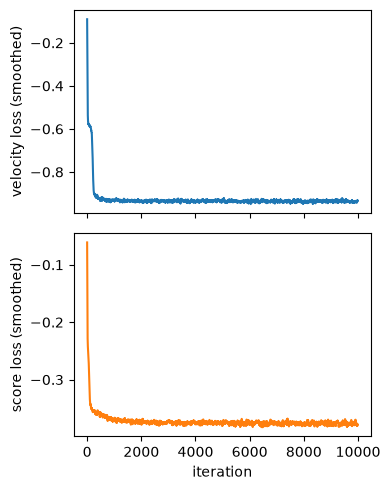

In [23]:
# Training curves (smoothed).
def smooth(v, k=20):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(2,1,sharex=True,figsize=(4,5))
ax[0].plot(smooth(hist_b),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Map base samples to the target with the model's built-in samplers:

- `model.sample_ode` integrates the probability-flow **ODE** `dx/dt = b(t, x)`
  with Heun's method (drift only).
- `model.sample_sde` integrates the reverse-time **SDE** with Euler–Maruyama,
  using both the drift `b` and the learned score `s` (diffusion `eps`).

In [25]:
# Draw base samples and push them through the model's built-in samplers.
torch.manual_seed(1)
batch = 20000
x0 = base.sample((batch,))
x1 = target.sample((batch,))

gen_ode = torch.clamp((model.sample_ode(x0, n_steps=100)+scale)/(2*scale),1e-4,1-1e-4)          # probability-flow ODE (drift only)
gen_sde = torch.clamp((model.sample_sde(x0, n_steps=100, eps=1)+scale)/(2*scale),1e-4,1-1e-4)     # reverse-time SDE (drift + score)

# How well do generated samples match the target? (mean log-dens
# ity)

ref = target.log_prob(x1).mean() - np.log(2.0*scale)
base_ref = base.log_prob(x0).mean()
print(f"mean target log-prob — ODE sampler : {target.log_prob(gen_ode).mean()- np.log(2.0*scale):+.3f}")
print(f"mean target log-prob — SDE sampler : {target.log_prob(gen_sde).mean()- np.log(2.0*scale):+.3f}")
print(f"mean target log-prob — true target : {ref:+.3f}")
print(f"mean base log-prob — true target : {base_ref:+.3f}")
print(f"estimated entropy change : {-ref + base_ref:+.3f}")

mean target log-prob — ODE sampler : -2.038
mean target log-prob — SDE sampler : -2.039
mean target log-prob — true target : -2.032
mean base log-prob — true target : -1.424
estimated entropy change : +0.608


### 5. Contour plotting

The analytic target density with generated samples overlaid — the **ODE**
sampler on the left, the **SDE** sampler on the right. Both should populate the
same modes as the target.

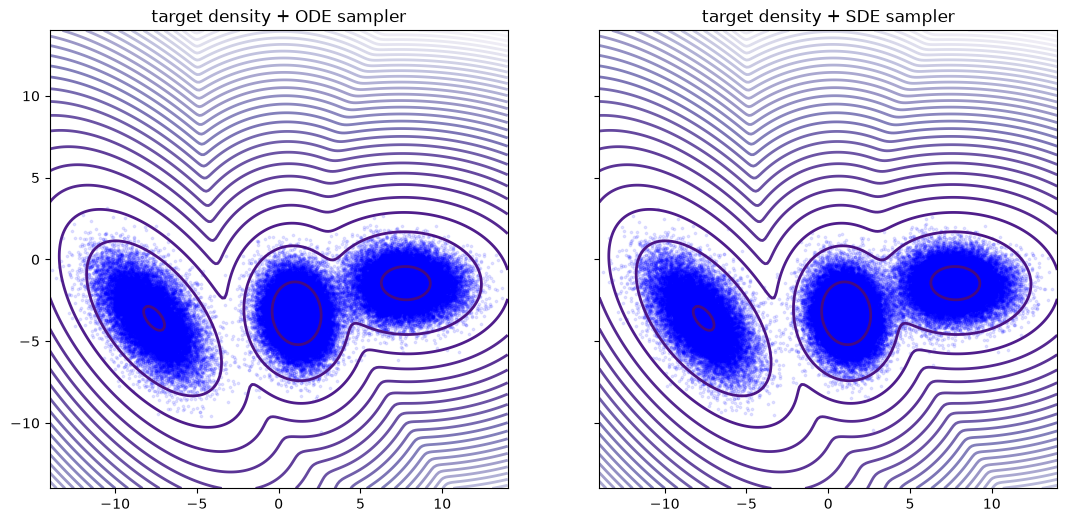

In [92]:
# Evaluate the target density on a grid (on-device), then move to CPU for plotting.
lo, hi, n = -LIM, LIM, 200
xs = torch.linspace(lo, hi, n, device=device)
gx, gy = torch.meshgrid(xs, xs, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=-1)
dens = target.log_prob(grid).reshape(n, n)
gx, gy, dens = gx.cpu(), gy.cpu(), dens.cpu()

fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for a, samples, title in [(ax[0], gen_ode, "ODE sampler"), (ax[1], gen_sde, "SDE sampler")]:
    s = samples.cpu()
    a.contour(gx, gy, dens, levels=30, cmap="Purples", lw=2)
    a.scatter(s[:, 0], s[:, 1], s=3, c="b", alpha=0.1)
    a.set_title(f"target density + {title}")
    a.set_aspect("equal"); a.set_xlim(lo, hi); a.set_ylim(lo, hi)
plt.show()

### 6. Entropy along the paths

The trajectory-returning `*_entropy_traj` samplers augment every path with the
running integral

$$\Delta\text{S}(t) = -\int_0^t b(x_{t'}, t')\cdot s(x_{t'}, t')\,dt',$$

an estimate of how the (differential) entropy of the flowing density changes as
samples move from base to target. With `sample_ode_entropy_traj` we get the full
`ΔS(t)` curve for every sample at once, so we can plot many paths together
and read off the ensemble-mean entropy change.

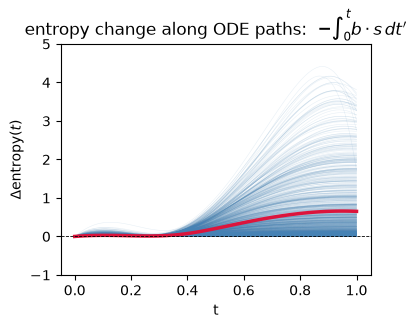

mean ΔS(1)  (base → target): +0.652


In [27]:
# Trace the running entropy change along many ODE paths.
torch.manual_seed(1)
batch = 20000
x0 = base.sample((batch,))
x1 = 8*(target.sample((batch,))-0.5)

traj, ent_traj, ts = model.sample_sde_entropy_traj(x0, n_steps=100)

ts_c = ts.cpu().numpy()[:1000]
ent_c = ent_traj.cpu().numpy()[:,:1000]         # [n_steps+1, B]

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c, c="steelblue", lw=0.4, alpha=0.12)                  # individual paths
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta$entropy$(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
#ax.legend()
ax.set_ylim(-1,5)
plt.show()

print(f"mean ΔS(1)  (base → target): {ent_c[-1].mean():+.3f}")

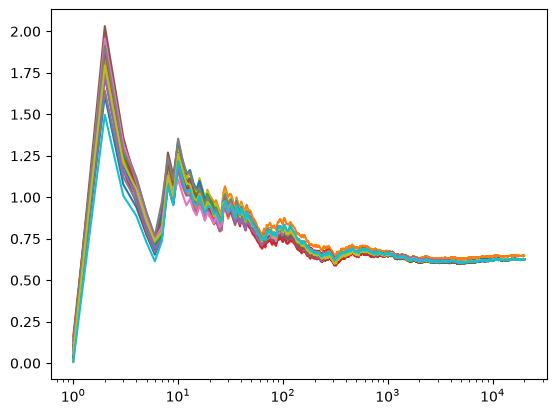

0.62615335
0.0051204073


In [46]:
# Trace the running entropy change along many ODE paths.
vals = []
torch.manual_seed(1)
batch = 20000
x0 = base.sample((batch,))
for k in range(20):
    torch.manual_seed(k)
    x,ent = model.sample_sde_entropy(x0,eps=0.2, n_steps=100)
    ent_cpu = ent.cpu().numpy()
    vals.append(np.mean(ent_cpu))
    #print(np.mean(ent_cpu))
    mean = np.cumsum(ent_cpu)/np.arange(1,batch+1)
    plt.plot(np.arange(1,batch+1),mean,'-')
#plt.yscale('log')
plt.xscale('log')
plt.show()
print(np.mean(vals))
print(np.std(vals))


### Generation-Free Entropy Estimate

In [52]:
torch.manual_seed(1)
batch = 20000
x0 = base.sample((batch,))
x1 = 8*(target.sample((batch,))-0.5)

means = []
for n in range(1000):
    torch.manual_seed(n)
    ent = model.entropy_estimate_dot(x1,x0)
    means.append(ent.mean().cpu().numpy())
print(np.mean(means))
print(np.std(means))

0.6198085
0.009070506


In [54]:

torch.manual_seed(1)
batch = 20000
x0 = base.sample((batch,))
x1 = 8*(target.sample((batch,))-0.5)

means = []
for n in range(1000):
    ent = model.entropy_estimate_div(x1,x0)
    means.append(ent.mean().detach().cpu().numpy())
print(np.mean(means))
print(np.std(means))

0.6188519
0.0054455106


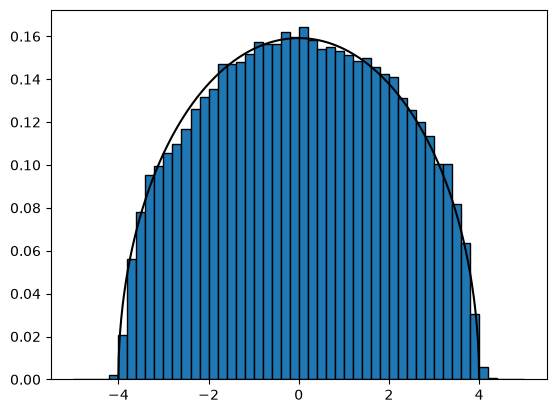

In [28]:
N = 100000
x0 = base.sample((N,))
x1 = model.sample_sde(x0, n_steps=100)
x1_cpu = x1.cpu().numpy()

plt.hist(x1_cpu,bins=np.linspace(-5,5,51),edgecolor='k',density=True)
xspace = np.linspace(-4,4,1001)
prb = scipy.special.gamma(3)*np.power(4+xspace,0.5)*np.power(4-xspace,0.5)/(64.0*scipy.special.gamma(1.5)**2)
plt.plot(xspace,prb,'-k')
plt.show()



### Analyzing Score

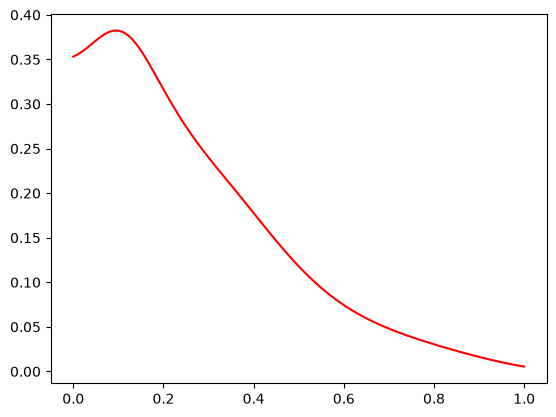

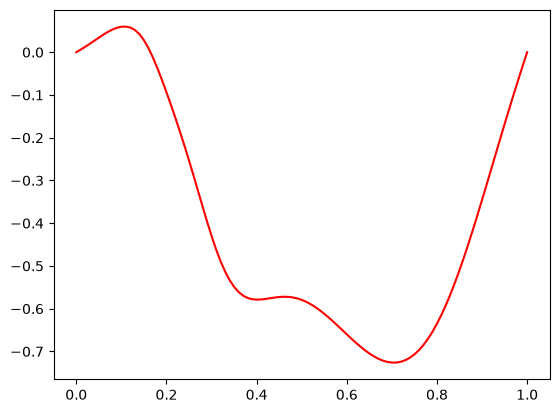

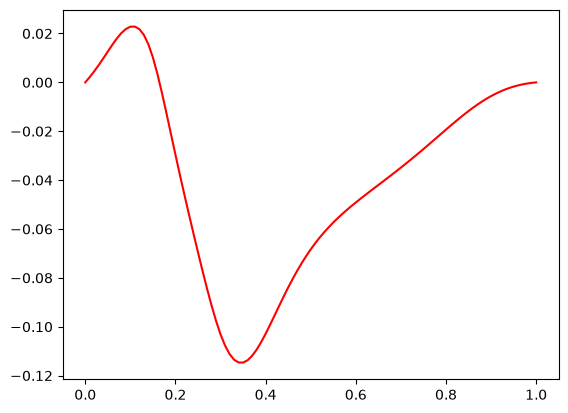

In [18]:
torch.manual_seed(51)
x0 = base.sample((1,))
traj, ent_traj, ts = model.sample_ode_entropy_traj(x0, n_steps=100)
ts_c = ts.cpu().numpy()
score = model.net_s(ts,traj[:,0,:]).detach().cpu()
vel = model.net_b(ts,traj[:,0,:]).detach().cpu()

plt.plot(ts_c,score,'-r')
#plt.plot(ts_c,score[:,1],'-b')
plt.show()

plt.plot(ts_c,vel,'-r')
#plt.plot(ts_c,vel[:,1],'-b')
plt.show()

plt.plot(ts_c,score*vel,'-r')
#plt.plot(ts_c,score[:,1]*vel[:,1],'-b')
plt.show()

[6.41746414e-04 5.76583784e-03 1.59614406e-02 3.11239339e-02
 5.10977302e-02 7.56778713e-02 1.04612132e-01 1.37603606e-01
 1.74313759e-01 2.14365892e-01 2.57349019e-01 3.02822072e-01
 3.50318439e-01 3.99350740e-01 4.49415839e-01 5.00000000e-01
 5.50584161e-01 6.00649260e-01 6.49681561e-01 6.97177928e-01
 7.42650981e-01 7.85634108e-01 8.25686241e-01 8.62396394e-01
 8.95387868e-01 9.24322129e-01 9.48902270e-01 9.68876066e-01
 9.84038559e-01 9.94234162e-01 9.99358254e-01]


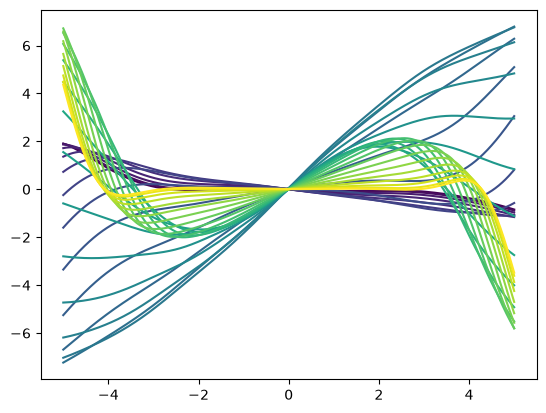

In [29]:
torch.manual_seed(51)
x0 = torch.linspace(-5,5,2001,device=device).unsqueeze(-1)
x = x0.cpu()
n = 31
tnodes = 0.5*(1-np.cos(np.pi*(np.arange(n)+0.5)/n))
print(tnodes)

for tval,color in zip(tnodes,plt.cm.viridis(np.linspace(0,1,n))):

    score = model.net_s(torch.tensor([[tval]],device=device).expand(2001,1),x0).detach().cpu()
    vel = model.net_b(torch.tensor([[tval]],device=device).expand(2001,1),x0).detach().cpu()
    

    #plt.plot(x,score,'-r')
    plt.plot(x,vel,'-',c=color)
    #plt.plot(x,score,'-',c=color)
    #plt.plot(x,score*vel,'-',c=color)
    #plt.plot(x,vel*score,'-g')
#plt.plot(x,-x,'--k')
#plt.plot(x,-x/4,'--k')
#plt.ylim(-4,4)
#plt.xlim(-3,3)
plt.show()

#plt.plot(ts_c,vel,'-r')
#plt.plot(ts_c,vel[:,1],'-b')
#plt.show()

#plt.plot(ts_c,score*vel,'-r')
#plt.plot(ts_c,score[:,1]*vel[:,1],'-b')
#plt.show()

In [20]:
model.net_b.center

Parameter containing:
tensor([0.], device='cuda:0', requires_grad=True)